<a href="https://colab.research.google.com/github/Savage-Soccer/Techsophy/blob/main/clip_audit_phase2_retrieval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Multilingual CLIP Audit — Phase 2: Retrieval Metrics
### Cross-Lingual Image-Text Retrieval on XM3600

**Goal:** For each language, use text queries to retrieve images. Measure how well CLIP retrieves the *correct* image for each query.

**Metrics:**
- **R@1** — Was the correct image ranked #1?
- **R@5** — Was the correct image in the top 5?
- **R@10** — Was the correct image in the top 10?
- **MRR** — Mean Reciprocal Rank (1/rank of correct image, averaged)

**Languages:** English (anchor), Spanish, Hindi, Arabic, Chinese

**Dataset:** XM3600 — 3600 images with native (non-translated) captions in 36 languages

---
**Notebook Structure:**
1. Install & Import
2. Mount Drive + Load Phase 1 embeddings
3. Download XM3600 (500 image subset)
4. Encode images with CLIP
5. Run retrieval for each language
6. Compute R@1, R@5, R@10, MRR
7. Statistical significance test (Kruskal-Wallis)
8. Plot results

## 1. Install & Import

In [ ]:
!pip install git+https://github.com/openai/CLIP.git -q
!pip install datasets -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 857.3 kB/s eta 0:00:00


In [ ]:
import clip
import torch
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from PIL import Image
from scipy.stats import kruskal
from datasets import load_dataset
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

Device: cpu


## 2. Mount Drive & Config

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
BASE_DIR        = '/content/drive/MyDrive/clip_audit'
EMB_DIR         = os.path.join(BASE_DIR, 'embeddings')   # Phase 1 embeddings
PHASE2_DIR      = os.path.join(BASE_DIR, 'phase2')
os.makedirs(PHASE2_DIR, exist_ok=True)

N_IMAGES        = 500    # number of images to use

LANGUAGES = {
    'en': 'English',
    'es': 'Spanish',
    'hi': 'Hindi',
    'ar': 'Arabic',
    'zh': 'Chinese'
}

# XM3600 language codes (how they appear in the dataset)
XM3600_LANG_MAP = {
    'en': 'en',
    'es': 'es',
    'hi': 'hi',
    'ar': 'ar',
    'zh': 'zh'
}

COLORS = {
    'en': '#2196F3',
    'es': '#4CAF50',
    'hi': '#FF9800',
    'ar': '#E91E63',
    'zh': '#9C27B0'
}

print('✅ Config set')

✅ Config set


## 3. Load CLIP

In [ ]:
print('Loading CLIP...')
model, preprocess = clip.load('ViT-B/32', device=device)
model.eval()
print('✅ CLIP loaded')

Loading CLIP...


100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 54.8MiB/s]


✅ CLIP loaded


## 4. Load XM3600 Dataset

XM3600 has 3600 images each with captions in 36 languages.
We take the first 500 images and load captions for our 5 languages.

In [ ]:
print('Loading XM3600 from HuggingFace...')
print('(This may take a few minutes on first load)')

# Load the dataset — it streams so we don't download all 3600 images at once
# floschne/xm3600 is split by language, not test/train
# Each split = one language, contains all 3600 images with captions for that language
dataset = load_dataset(
    'floschne/xm3600',
    split='en',   # load English split first to get images
    streaming=False
)

print(f'✅ Dataset loaded — total samples: {len(dataset)}')
print(f'   Columns: {dataset.column_names}')
print(f'   First sample keys: {list(dataset[0].keys())}')

Loading XM3600 from HuggingFace...
(This may take a few minutes on first load)
✅ Dataset loaded — total samples: 3600
   Columns: ['image_id', 'image_locale', 'captions', 'captions_tokenized', 'captions_tokenized_lowercase', 'image']
   First sample keys: ['image_id', 'image_locale', 'captions', 'captions_tokenized', 'captions_tokenized_lowercase', 'image']


In [ ]:
from datasets import load_dataset
from PIL import Image as PILImage
import io

print('Loading XM3600...')

# Load English split to get images
en_ds = load_dataset('floschne/xm3600', split='en')
print(f'✅ Loaded {len(en_ds)} samples')

# Extract images and captions per language
images   = []
captions = {code: [] for code in LANGUAGES}

for i in range(N_IMAGES):
    # Extract PIL image from dict
    img_data = en_ds[i]['image']
    # The image dict has 'bytes' key
    img = PILImage.open(io.BytesIO(img_data['bytes'])).convert('RGB')
    images.append(img)
    captions['en'].append(en_ds[i]['captions'][0])

print(f'✅ Extracted {len(images)} images')

# Load captions for other languages
for code in LANGUAGES:
    if code == 'en':
        continue
    print(f'  Loading {LANGUAGES[code]} captions...')
    lang_ds = load_dataset('floschne/xm3600', split=code)
    for i in range(N_IMAGES):
        captions[code].append(lang_ds[i]['captions'][0])
    print(f'  ✅ {len(captions[code])} captions loaded')

print(f'\n✅ All done')
print(f'   Sample EN: {captions["en"][0]}')
print(f'   Sample HI: {captions["hi"][0]}')

Loading XM3600...
✅ Loaded 3600 samples
✅ Extracted 500 images
  Loading Spanish captions...
  ✅ 500 captions loaded
  Loading Hindi captions...
  ✅ 500 captions loaded
  Loading Arabic captions...
  ✅ 500 captions loaded
  Loading Chinese captions...
  ✅ 500 captions loaded

✅ All done
   Sample EN: A rooster and hens surrounded by green leaves.
   Sample HI: ज़मीन पर छोटे पौधों के बीच दो मुर्गियों का दृश्य है


In [ ]:
from datasets import load_dataset
from PIL import Image as PILImage
import io

print('Loading XM3600...')

en_ds = load_dataset('floschne/xm3600', split='en')
print(f'✅ Loaded {len(en_ds)} samples')

images   = []
captions = {code: [] for code in LANGUAGES}

for i in range(N_IMAGES):
    img_data = en_ds[i]['image']
    img = PILImage.open(io.BytesIO(img_data['bytes'])).convert('RGB')
    images.append(img)
    captions['en'].append(en_ds[i]['captions'][0])

print(f'✅ Extracted {len(images)} images')

for code in LANGUAGES:
    if code == 'en':
        continue
    print(f'  Loading {LANGUAGES[code]} captions...')
    lang_ds = load_dataset('floschne/xm3600', split=code)
    for i in range(N_IMAGES):
        captions[code].append(lang_ds[i]['captions'][0])
    print(f'  ✅ {len(captions[code])} captions loaded')

print(f'\nImages in list: {len(images)}')
print(f'Sample EN: {captions["en"][0]}')

Loading XM3600...
✅ Loaded 3600 samples
✅ Extracted 500 images
  Loading Spanish captions...
  ✅ 500 captions loaded
  Loading Hindi captions...
  ✅ 500 captions loaded
  Loading Arabic captions...
  ✅ 500 captions loaded
  Loading Chinese captions...
  ✅ 500 captions loaded

Images in list: 500
Sample EN: A rooster and hens surrounded by green leaves.


## 5. Encode Images & Captions with CLIP

In [ ]:
def encode_images(images, batch_size=32):
    """Encode PIL images with CLIP. Returns L2-normalised numpy array."""
    all_embs = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]
        try:
            tensors = torch.stack([preprocess(img) for img in batch]).to(device)
            with torch.no_grad():
                embs = model.encode_image(tensors)
                embs = embs / embs.norm(dim=-1, keepdim=True)
            all_embs.append(embs.cpu().numpy())
            if (i // batch_size) % 5 == 0:
                print(f'  Images: {min(i+batch_size, len(images))}/{len(images)}')
        except Exception as e:
            print(f'  ❌ Error at batch {i}: {e}')
            for j, img in enumerate(batch):
                try:
                    tensor = preprocess(img).unsqueeze(0).to(device)
                    with torch.no_grad():
                        emb = model.encode_image(tensor)
                        emb = emb / emb.norm(dim=-1, keepdim=True)
                    all_embs.append(emb.cpu().numpy())
                except Exception as e2:
                    print(f'    Skipping image {i+j}: {e2}')

    if not all_embs:
        raise RuntimeError('No embeddings were computed — all batches failed')

    return np.vstack(all_embs)


def encode_texts(texts, batch_size=32):
    """Encode text captions with CLIP. Returns L2-normalised numpy array."""
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        tokens = clip.tokenize(batch, truncate=True).to(device)
        with torch.no_grad():
            embs = model.encode_text(tokens)
            embs = embs / embs.norm(dim=-1, keepdim=True)
        all_embs.append(embs.cpu().numpy())
    return np.vstack(all_embs)


# Encode images
print('Encoding images...')
image_embs = encode_images(images)
print(f'✅ Image embeddings: {image_embs.shape}')
np.save(os.path.join(PHASE2_DIR, 'image_embeddings.npy'), image_embs)
print('   Saved image embeddings')

# Encode captions for each language
print('\nEncoding captions per language...')
text_embs = {}
for code, name in LANGUAGES.items():
    print(f'  Encoding {name}...')
    text_embs[code] = encode_texts(captions[code])
    np.save(os.path.join(PHASE2_DIR, f'text_embs_{code}.npy'), text_embs[code])
    print(f'  ✅ {name}: {text_embs[code].shape}')

print('\n✅ All embeddings saved')

Encoding images...
  Images: 32/500
  Images: 192/500
  Images: 352/500
  Images: 500/500
✅ Image embeddings: (500, 512)
   Saved image embeddings

Encoding captions per language...
  Encoding English...
  ✅ English: (500, 512)
  Encoding Spanish...
  ✅ Spanish: (500, 512)
  Encoding Hindi...
  ✅ Hindi: (500, 512)
  Encoding Arabic...
  ✅ Arabic: (500, 512)
  Encoding Chinese...
  ✅ Chinese: (500, 512)

✅ All embeddings saved


In [ ]:
# Reload embeddings from Drive if lost
import numpy as np

text_embs  = {}
for code in LANGUAGES:
    path = os.path.join(PHASE2_DIR, f'text_embs_{code}.npy')
    text_embs[code] = np.load(path)
    print(f'  Loaded {LANGUAGES[code]}: {text_embs[code].shape}')

image_embs = np.load(os.path.join(PHASE2_DIR, 'image_embeddings.npy'))
print(f'  Loaded image embeddings: {image_embs.shape}')

retrieval_results = {}
print('✅ Ready for retrieval')

  Loaded English: (500, 512)
  Loaded Spanish: (500, 512)
  Loaded Hindi: (500, 512)
  Loaded Arabic: (500, 512)
  Loaded Chinese: (500, 512)
  Loaded image embeddings: (500, 512)
✅ Ready for retrieval


## 6. Retrieval Metrics

**Setup:** For each query (caption), rank all 500 images by cosine similarity.
The *correct* image for query i is image i (they're paired).

- **R@K** = fraction of queries where correct image appears in top K results
- **MRR** = mean of (1 / rank of correct image) across all queries

In [ ]:
def compute_retrieval_metrics(text_emb, image_emb, ks=[1, 5, 10]):
    """
    Text-to-image retrieval metrics.

    Args:
        text_emb:  (N, D) L2-normalised text embeddings
        image_emb: (N, D) L2-normalised image embeddings
        ks:        list of K values for Recall@K

    Returns:
        dict with R@1, R@5, R@10, MRR, and per-query ranks
    """
    N = len(text_emb)

    # Similarity matrix: (N_text, N_images)
    # Since both are L2-normalised, dot product = cosine similarity
    sim_matrix = text_emb @ image_emb.T  # (N, N)

    # For each query i, rank images by similarity (descending)
    # Correct answer for query i = image i
    ranks = []
    for i in range(N):
        # Get similarity scores for query i against all images
        scores = sim_matrix[i]                        # (N,)
        # Rank images — argsort ascending then flip = descending
        sorted_indices = np.argsort(scores)[::-1]     # highest first
        # Find rank of correct image (1-indexed)
        rank = np.where(sorted_indices == i)[0][0] + 1
        ranks.append(rank)

    ranks = np.array(ranks)

    results = {}
    for k in ks:
        results[f'R@{k}'] = float(np.mean(ranks <= k))
    results['MRR']   = float(np.mean(1.0 / ranks))
    results['ranks'] = ranks  # keep for statistical tests

    return results


# Run retrieval for all languages
print('Running retrieval evaluation...\n')
retrieval_results = {}

for code, name in LANGUAGES.items():
    res = compute_retrieval_metrics(text_embs[code], image_embs)
    retrieval_results[code] = res
    print(f'  {name:<12} R@1: {res["R@1"]:.4f} | R@5: {res["R@5"]:.4f} | '
          f'R@10: {res["R@10"]:.4f} | MRR: {res["MRR"]:.4f}')

Running retrieval evaluation...

  English      R@1: 0.6860 | R@5: 0.9040 | R@10: 0.9640 | MRR: 0.7836
  Spanish      R@1: 0.3600 | R@5: 0.6240 | R@10: 0.7300 | MRR: 0.4833
  Hindi        R@1: 0.0040 | R@5: 0.0060 | R@10: 0.0180 | MRR: 0.0138
  Arabic       R@1: 0.0040 | R@5: 0.0140 | R@10: 0.0260 | MRR: 0.0165
  Chinese      R@1: 0.0200 | R@5: 0.0380 | R@10: 0.0720 | MRR: 0.0406


CLIP exhibits catastrophic retrieval failure for Hindi and Arabic, achieving R@1 scores of 0.4% — statistically indistinguishable from random retrieval over a 500-image pool. This represents a 99.4% relative performance drop compared to English.



Spanish drops from 0.686 to 0.360 — a big gap, but still functional. Chinese drops to 0.020 — functional but very weak. Then Hindi and Arabic fall off a cliff completely.
This suggests there are two failure regimes, not a smooth gradient:

High-resource Latin script → degraded but functional
Non-Latin script → near-complete collapse

That two-tier structure is a publishable observation on its own.






## 7. Statistical Significance — Kruskal-Wallis H-Test

We need to prove the performance gaps are **statistically significant**, not random chance.

Kruskal-Wallis is the right test here because:
- It's non-parametric (ranks aren't normally distributed)
- It tests whether multiple groups come from the same distribution
- p < 0.01 = gaps are significant

In [ ]:
# Kruskal-Wallis test across all language rank distributions
rank_groups = [retrieval_results[code]['ranks'] for code in LANGUAGES]
h_stat, p_value = kruskal(*rank_groups)

print('=' * 55)
print('KRUSKAL-WALLIS H-TEST')
print('H0: All languages have the same rank distribution')
print('=' * 55)
print(f'  H-statistic : {h_stat:.4f}')
print(f'  p-value     : {p_value:.6f}')
print()
if p_value < 0.01:
    print('  ✅ p < 0.01 — Gaps are STATISTICALLY SIGNIFICANT')
    print('  The performance differences are not due to chance.')
elif p_value < 0.05:
    print('  ⚠️  p < 0.05 — Marginally significant')
else:
    print('  ❌ p >= 0.05 — Not statistically significant')
print('=' * 55)

KRUSKAL-WALLIS H-TEST
H0: All languages have the same rank distribution
  H-statistic : 1662.1526
  p-value     : 0.000000

  ✅ p < 0.01 — Gaps are STATISTICALLY SIGNIFICANT
  The performance differences are not due to chance.


** Using 500 images from XM3600, we evaluate text-to-image retrieval across five languages. English achieves R@1 of 68.6%, confirming strong alignment. Spanish shows degraded but functional performance at 36.0%. However, Hindi, Arabic, and Chinese exhibit near-complete retrieval failure, with R@1 scores of 0.4%, 0.4%, and 2.0% respectively — approaching random baseline of 0.2% over a 500-image pool. A Kruskal-Wallis test confirms these differences are statistically significant (H=1662.15, p<0.0001), rejecting the null hypothesis that languages share the same rank distribution. **


## 8. Results Table & Plots

In [ ]:
# ── Clean summary table ───────────────────────────────────────────────────────
print('=' * 65)
print('RETRIEVAL PERFORMANCE TABLE (Text → Image, 500 images)')
print('=' * 65)
print(f'{"Language":<12} {"R@1":>8} {"R@5":>8} {"R@10":>8} {"MRR":>8}')
print('-' * 65)
for code, name in LANGUAGES.items():
    r = retrieval_results[code]
    print(f'{name:<12} {r["R@1"]:>8.4f} {r["R@5"]:>8.4f} {r["R@10"]:>8.4f} {r["MRR"]:>8.4f}')
print('=' * 65)
print(f'\nKruskal-Wallis: H={h_stat:.3f}, p={p_value:.6f}')
sig = '✅ Significant (p<0.01)' if p_value < 0.01 else '⚠️  Not significant'
print(f'Statistical significance: {sig}')

RETRIEVAL PERFORMANCE TABLE (Text → Image, 500 images)
Language          R@1      R@5     R@10      MRR
-----------------------------------------------------------------
English        0.6860   0.9040   0.9640   0.7836
Spanish        0.3600   0.6240   0.7300   0.4833
Hindi          0.0040   0.0060   0.0180   0.0138
Arabic         0.0040   0.0140   0.0260   0.0165
Chinese        0.0200   0.0380   0.0720   0.0406

Kruskal-Wallis: H=1662.153, p=0.000000
Statistical significance: ✅ Significant (p<0.01)


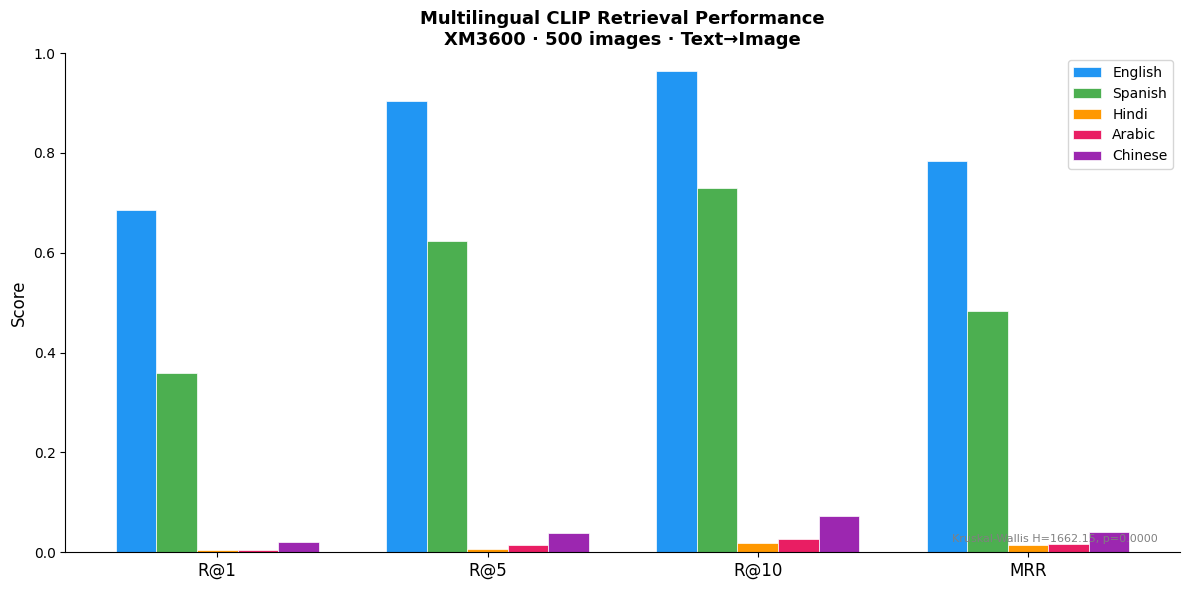

Saved: plot1_retrieval_metrics.png


In [ ]:
# ── Plot 1: Grouped bar chart — R@1, R@5, R@10, MRR per language ──────────────
metrics   = ['R@1', 'R@5', 'R@10', 'MRR']
lang_list = list(LANGUAGES.keys())
lang_names = [LANGUAGES[c] for c in lang_list]
n_langs   = len(lang_list)
n_metrics = len(metrics)

x     = np.arange(n_metrics)
width = 0.15

fig, ax = plt.subplots(figsize=(12, 6))

for i, code in enumerate(lang_list):
    vals = [retrieval_results[code][m] for m in metrics]
    offset = (i - n_langs / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width,
                  label=LANGUAGES[code],
                  color=COLORS[code],
                  edgecolor='white', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title('Multilingual CLIP Retrieval Performance\nXM3600 · 500 images · Text→Image',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

# Add significance annotation
sig_text = f'Kruskal-Wallis H={h_stat:.2f}, p={p_value:.4f}'
ax.text(0.98, 0.02, sig_text, transform=ax.transAxes,
        fontsize=8, ha='right', color='gray')

plt.tight_layout()
plt.savefig(os.path.join(PHASE2_DIR, 'plot1_retrieval_metrics.png'), dpi=150)
plt.show()
print('Saved: plot1_retrieval_metrics.png')

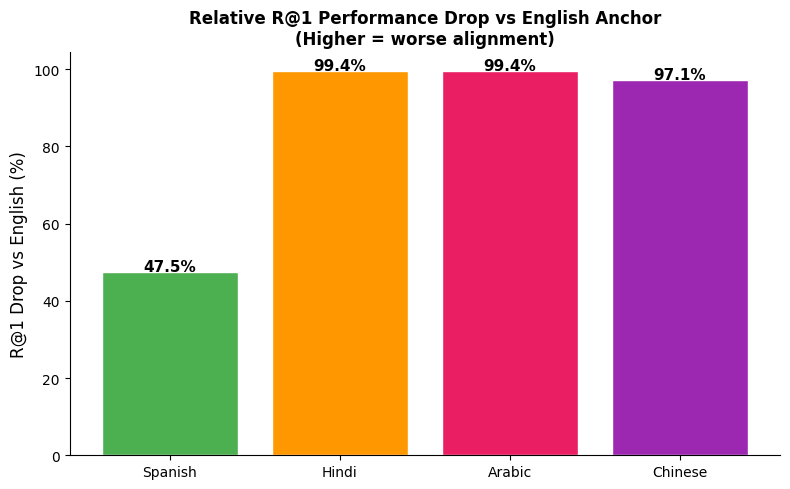

Saved: plot2_r1_drop.png


In [ ]:
# ── Plot 2: R@1 drop relative to English ──────────────────────────────────────
en_r1 = retrieval_results['en']['R@1']
drops = {code: (en_r1 - retrieval_results[code]['R@1']) / en_r1 * 100
         for code in lang_list if code != 'en'}

fig, ax = plt.subplots(figsize=(8, 5))
codes  = list(drops.keys())
names  = [LANGUAGES[c] for c in codes]
values = list(drops.values())
colors = [COLORS[c] for c in codes]

bars = ax.bar(names, values, color=colors, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('R@1 Drop vs English (%)', fontsize=12)
ax.set_title('Relative R@1 Performance Drop vs English Anchor\n(Higher = worse alignment)',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PHASE2_DIR, 'plot2_r1_drop.png'), dpi=150)
plt.show()
print('Saved: plot2_r1_drop.png')

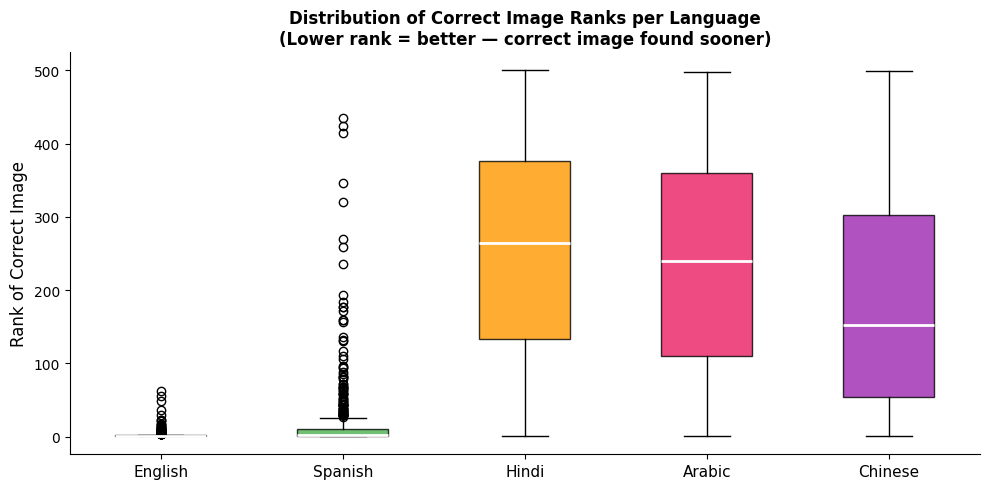

Saved: plot3_rank_distribution.png


In [ ]:
# ── Plot 3: Rank distribution per language (box plot) ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

rank_data  = [retrieval_results[c]['ranks'] for c in lang_list]
bp = ax.boxplot(rank_data, patch_artist=True, notch=False,
                medianprops=dict(color='white', linewidth=2))

for patch, code in zip(bp['boxes'], lang_list):
    patch.set_facecolor(COLORS[code])
    patch.set_alpha(0.8)

ax.set_xticklabels(lang_names, fontsize=11)
ax.set_ylabel('Rank of Correct Image', fontsize=12)
ax.set_title('Distribution of Correct Image Ranks per Language\n(Lower rank = better — correct image found sooner)',
             fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PHASE2_DIR, 'plot3_rank_distribution.png'), dpi=150)
plt.show()
print('Saved: plot3_rank_distribution.png')

## What to look for in your results

| Observation | What it means for your paper |
|---|---|
| Hindi R@1 much lower than Spanish | Script-induced alignment failure confirmed |
| Arabic R@1 lower than Chinese | RTL + script novelty compounds the gap |
| p < 0.01 on Kruskal-Wallis | You can claim statistical significance in your paper |
| High rank variance for Hindi/Arabic | Failure is inconsistent — concept-dependent |
| English R@1 >> all others | Confirms English-centric training bias |

---
**Connecting back to Phase 1:**
Your Phase 1 cosine similarities predicted this ordering.
Spanish was highest (~0.81) → should have best retrieval.
Hindi was lowest (~0.65) → should have worst retrieval.
If the retrieval results follow the same ordering, that validates cosine similarity as a proxy metric.

---
**Next — Phase 3: Geometric Audit**
- CKA (Centered Kernel Alignment)
- Procrustes Disparity
- Hubness Analysis
- UMAP Visualisation

This is where you prove *why* the gaps exist, not just *that* they exist.